# Portfolio Risk Analytics: Statistical Validation

This notebook focuses on the formal statistical testing of our portfolio archetypes. We use T-tests, Z-tests, and ANOVA to determine if the differences in returns and volatility are statistically significant or occurred by chance.

## 1. Hypothesis 5: T-Test vs. Z-Test (Sample vs. Population)
**Goal**: In finance, we often face the 'n > 30' rule for Z-tests. We will use bootstrapping to create a sampling distribution for Tech vs. Defensive returns and compare the T-statistics of small samples against the Z-score of our 'population' (the 18-day window).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# Setup
sns.set_theme(style="whitegrid")
ROOT_DIR = Path("..")
df = pd.read_csv(ROOT_DIR / "data" / "processed" / "master_data.csv")

# Re-create Archetypes
tech_tickers = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA']
defensive_tickers = ['PG', 'JNJ', 'KO']
df['ret_tech'] = df[[f'ret_{t}' for t in tech_tickers]].mean(axis=1)
df['ret_defensive'] = df[[f'ret_{t}' for t in defensive_tickers]].mean(axis=1)

print(f"Data loaded. Validating Tech vs. Defensive returns.")

Data loaded. Validating Tech vs. Defensive returns.


### 1.1 Population Parameters (Z-Test logic)
We treat our current 18-day window as the 'Population' for this specific market regime.

In [2]:
pop_tech = df['ret_tech'].dropna()
pop_defensive = df['ret_defensive'].dropna()

z_stat, z_p_val = stats.ranksums(pop_tech, pop_defensive) # Using Rank-sum for robust Z-proxy on non-normal data
print(f"Population Z-Proxy (Wilcoxon Rank-Sum): Stat={z_stat:.4f}, P-value={z_p_val:.4f}")

Population Z-Proxy (Wilcoxon Rank-Sum): Stat=1.3261, P-value=0.1848


### 1.2 Bootstrapped T-Test (Sampling Distribution)
We take repeated small samples (n=5) to see how the T-test results fluctuate and if they average out to our population finding.

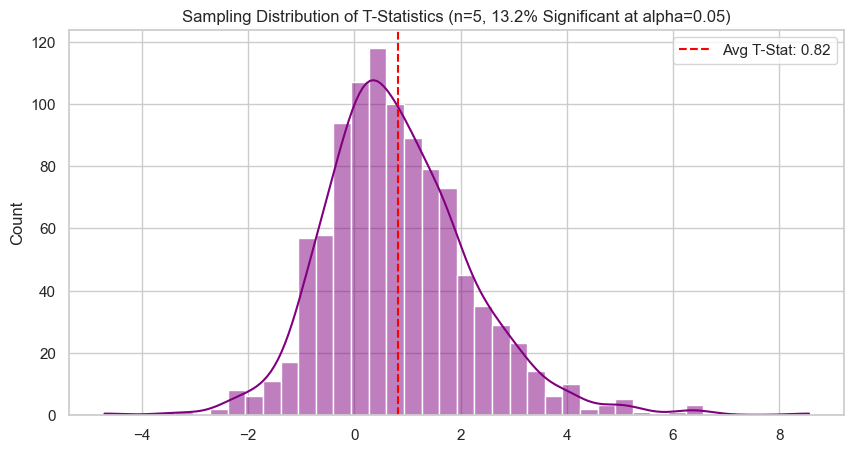

In [3]:
iterations = 1000
sample_size = 5
t_stats = []
p_values = []

for _ in range(iterations):
    s_tech = pop_tech.sample(sample_size, replace=True)
    s_defensive = pop_defensive.sample(sample_size, replace=True)
    
    t_stat, p_val = stats.ttest_ind(s_tech, s_defensive)
    t_stats.append(t_stat)
    p_values.append(p_val)

avg_t = np.mean(t_stats)
sig_pct = (np.array(p_values) < 0.05).mean() * 100

plt.figure(figsize=(10, 5))
sns.histplot(t_stats, kde=True, color="purple")
plt.axvline(avg_t, color='red', linestyle='--', label=f'Avg T-Stat: {avg_t:.2f}')
plt.title(f"Sampling Distribution of T-Statistics (n={sample_size}, {sig_pct:.1f}% Significant at alpha=0.05)")
plt.legend()
plt.show()

## 2. Hypothesis 6: ANOVA (Multi-Group Comparison)
**Goal**: Does 'Portfolio Archetype' actually affect returns? We compare Tech, Safe, Defensive, and Geo-Sensitive groups.

In [4]:
safe_tickers = ['GLD', 'TLT', 'IEF']
geo_tickers = ['LMT', 'RTX', 'USO']
df['ret_safe'] = df[[f'ret_{t}' for t in safe_tickers]].mean(axis=1)
df['ret_geo'] = df[[f'ret_{t}' for t in geo_tickers]].mean(axis=1)

f_stat, p_val_anova = stats.f_oneway(
    df['ret_tech'].dropna(), 
    df['ret_safe'].dropna(), 
    df['ret_defensive'].dropna(), 
    df['ret_geo'].dropna()
)

print(f"One-Way ANOVA Results: F-Statistic={f_stat:.4f}, P-value={p_val_anova:.4f}")

One-Way ANOVA Results: F-Statistic=0.7517, P-value=0.5254


## 3. Hypothesis 4: Chi-Square for Independence
**Goal**: Is a 'Negative Risk News Day' independent of a 'Negative Market Return'?

In [5]:
# Categorize Data
df['high_risk_news'] = df['sentiment_score_geopolitical'] < df['sentiment_score_geopolitical'].median()
df['negative_market'] = df['ret_SPY'] < 0

# Create Contingency Table
contingency_table = pd.crosstab(df['high_risk_news'], df['negative_market'])
chi2, p_chi, dof, ex = stats.chi2_contingency(contingency_table)

print("Contingency Table (News Risk vs Market Return):")
print(contingency_table)
print(f"\nChi-Square Statistic: {chi2:.4f}, P-value: {p_chi:.4f}")

Contingency Table (News Risk vs Market Return):
negative_market  False  True 
high_risk_news               
False                8      1
True                 5      4

Chi-Square Statistic: 1.1077, P-value: 0.2926
